# Solving the Traveling Salesman  Problem using Local Search

Points: 10

## The [Traveling Salesman Problem](https://en.wikipedia.org/wiki/Travelling_salesman_problem)

* __Goal:__ Find the shortest tour visiting each of $n$ cities exactly once and returning back to the starting city. Given are pairwise distances between cities, where $d_{i,j}$ is the distance from city $i$ to city $j$.

* __State space:__ Each state represents a tour. The cities are numbered and a tour can be expressed as vector  $\pi$ with the order in which the cities are visited (a [permutation](https://en.wikipedia.org/wiki/Permutation)). That is, $\pi(1)$ is the index of the first city to visit, $\pi(2)$ the index of the second, and so on.

* __Objective function:__ Minimize the tour length. The optimization problem is to find the optimal tour $\pi^*$ through the $n$ cities and returning to the starting city:

  > minimize: $\mathrm{tourlength}(\pi) = d_{\pi(n),\pi(1)} + \sum_{i = 1}^{n-1} d_{\pi(i),\pi(i+1)}$
  >
  > subject to: $\pi \ \text{is a valid permutation vector}$

* __Local moves:__ Exchange two cities in the order.

## Helper functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random

np.set_printoptions(precision=2)
pd.set_option('precision', 2)

# make the results repeatable
np.random.seed(1234)

In [ ]:
def random_tour(n):
    """Create a random tour"""

    tour = list(range(n))
    random.shuffle(tour)
    return(tour)

random_tour(10)

[1, 8, 0, 5, 7, 4, 6, 3, 2, 9]

In [ ]:
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

def random_tsp(n):
    """
    Create a random (Euclidean) traveling salesman problem. Choose n points randomly in a 1 x 1 unit square and calulates a
    pairwise Euclidean distance matrix.
    """

    pos = pd.DataFrame({
        "x" : np.random.uniform(size = n),
        "y" : np.random.uniform(size = n)
    })

    dist = squareform(pdist(pos))

    return({"pos": pos, "dist": dist})

tsp = random_tsp(10)

print(f"Positions:\n{tsp['pos']}")
print(f"Distance matrix:\n{pd.DataFrame(tsp['dist'])})")

Positions:
      x     y
0  0.19  0.36
1  0.62  0.50
2  0.44  0.68
3  0.79  0.71
4  0.78  0.37
5  0.27  0.56
6  0.28  0.50
7  0.80  0.01
8  0.96  0.77
9  0.88  0.88
Distance matrix:
      0     1     2     3     4     5     6     7     8     9
0  0.00  0.45  0.41  0.69  0.59  0.22  0.17  0.70  0.87  0.86
1  0.45  0.00  0.26  0.27  0.20  0.35  0.35  0.52  0.43  0.46
2  0.41  0.26  0.00  0.35  0.46  0.21  0.24  0.76  0.53  0.48
3  0.69  0.27  0.35  0.00  0.34  0.53  0.55  0.70  0.18  0.19
4  0.59  0.20  0.46  0.34  0.00  0.54  0.52  0.36  0.44  0.52
5  0.22  0.35  0.21  0.53  0.54  0.00  0.06  0.76  0.72  0.68
6  0.17  0.35  0.24  0.55  0.52  0.06  0.00  0.72  0.73  0.71
7  0.70  0.52  0.76  0.70  0.36  0.76  0.72  0.00  0.77  0.87
8  0.87  0.43  0.53  0.18  0.44  0.72  0.73  0.77  0.00  0.14
9  0.86  0.46  0.48  0.19  0.52  0.68  0.71  0.87  0.14  0.00)


In [ ]:
def tour_length(tsp, tour):
    """Caclulate the length of a tour, i.e., the objective function."""

    # make sure tour is a Python list (not an array or a numpy.array)
    if not isinstance(tour, list): tour = tour.tolist()

    tl = 0
    dist = tsp["dist"]

    for i in range(len(tour)-1):
        tl += dist[tour[i], tour[i+1]]

    tl += dist[tour[-1], tour[0]]

    return(tl)

tour = random_tour(10)
tour_length(tsp, tour)

4.799039732446266

Tour length: 4.8


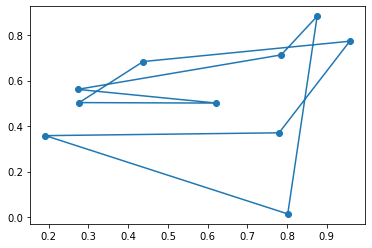

In [ ]:
def show_tsp(tsp, tour = None):
    """display the traveling salesman problem and a tour."""

    pos = tsp["pos"]

    plt.scatter(pos["x"], pos["y"])

    if tour is not None:
        # make sure tour is a Python list (not an array or a numpy.array)
        if not isinstance(tour, list): tour = tour.tolist()

        print(f"Tour length: {round(tour_length(tsp, tour), 2)}")

        pos_ = pos.reindex(tour)
        pos_ = pos_.append(pos_.head(1))
        plt.plot(pos_["x"], pos_["y"])

    plt.show()

show_tsp(tsp, tour)

## Use R to find a solution

Load rpy2, make sure the R [TSP package](https://CRAN.R-project.org/package=TSP) is installed and prepare the distance matrix.

In [ ]:
%load_ext rpy2.ipython

%R if(!"TSP" %in% rownames(installed.packages())) install.packages("TSP", repos="http://cran.us.r-project.org")
%R if(!"microbenchmark" %in% rownames(installed.packages())) install.packages("microbenchmark", repos="http://cran.us.r-project.org")

d = tsp["dist"]

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Solve the TSP using [`solve_TSP`](https://www.rdocumentation.org/packages/TSP/versions/1.1-10/topics/solve_TSP) with the default heuristic. Note that 2-opt is steepest ascend hill climbing with exchanging two cities. `rep=100` means 100 random restarts.

In [ ]:
%%R -i d -o tour

library("TSP")

tsp <- TSP(d)
print(tsp)

tour <- solve_TSP(tsp, rep = 100)
print(tour)

# R starts index with 1, but Python starts at 0
tour <- tour - 1L

object of class ‘TSP’ 
10 cities (distance ‘unknown’) 
object of class ‘TOUR’ 
result of method ‘arbitrary_insertion+two_opt_rep_100’ for 10 cities
tour length: 2.763574 


Tour length: 2.76


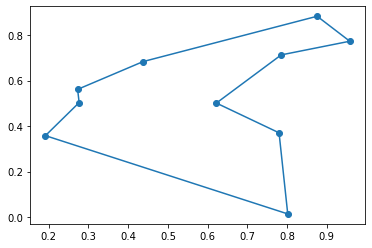

In [ ]:
show_tsp(tsp, tour)

How long does it take to solve the problem 100 times?

In [ ]:
%%R -i d

library("microbenchmark")

microbenchmark(tsp <- TSP(d))

Unit: microseconds
          expr    min      lq     mean median       uq     max neval
 tsp <- TSP(d) 287.99 302.479 324.9209 312.62 336.2445 616.048   100


## Steepest-ascend Hill Climbing Search [3 Points]

Calculate the objective function for all local moves (move each queen within its column) and always choose the best among all local moves.

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1️⃣ Tạo dữ liệu TSP (random tọa độ)
# -------------------------------------------------
def make_tsp(n=20, seed=1234):
    random.seed(seed)
    coords = np.random.rand(n, 2) * 100  # n điểm ngẫu nhiên trong vùng 100x100
    d = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                d[i, j] = np.linalg.norm(coords[i] - coords[j])
    return {"pos": coords, "d": d, "n": n}

# -------------------------------------------------
# 2️⃣ Hàm tiện ích
# -------------------------------------------------
def tour_length(tsp, tour):
    """Tính tổng chiều dài một tour."""
    d = tsp["d"]
    return sum(d[tour[i], tour[(i+1) % len(tour)]] for i in range(len(tour)))

def two_opt_swap(tour, i, k):
    """Thực hiện phép hoán đổi 2-opt."""
    new_tour = tour[:i] + tour[i:k+1][::-1] + tour[k+1:]
    return new_tour

def random_tour(n):
    """Tạo tour ngẫu nhiên gồm n thành phố."""
    tour = list(range(n))
    random.shuffle(tour)
    return tour

def show_tsp(tsp, tour, title="TSP Tour"):
    """Vẽ biểu đồ tour."""
    coords = tsp["pos"]
    plt.figure(figsize=(5,5))
    x = [coords[i][0] for i in tour] + [coords[tour[0]][0]]
    y = [coords[i][1] for i in tour] + [coords[tour[0]][1]]
    plt.plot(x, y, 'o-', color='tab:blue')
    for idx, (xx, yy) in enumerate(coords):
        plt.text(xx + 0.8, yy + 0.8, str(idx), fontsize=8)
    plt.title(title)
    plt.show()

# -------------------------------------------------
# 3️⃣ Khởi tạo bài toán TSP mẫu
# -------------------------------------------------
tsp = make_tsp(20, seed=42)
print(f"TSP created with {tsp['n']} cities.")


TSP created with 20 cities.


Steepest-ascent result: length=436.313202, iterations=15


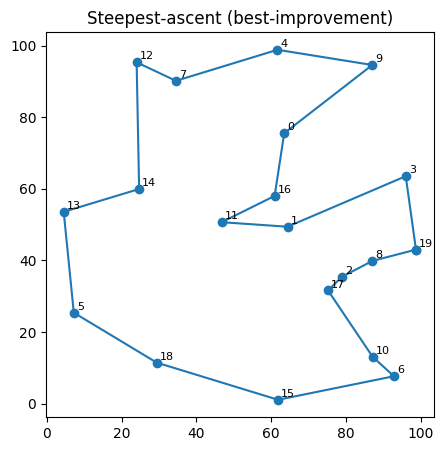

In [ ]:
# Code goes here
# Steepest-ascent hill climbing (2-opt best-improvement)
# Assumes: tsp (with tsp["pos"], tsp["dist"]), random_tour, tour_length, two_opt_swap exist.

def steepest_ascent_2opt(tsp, init_tour=None, max_iters=1000):
    """
    Best-improvement 2-opt hill climbing.
    Returns (best_tour, best_length, iters_used)
    """
    n = len(tsp["pos"])
    if init_tour is None:
        current = random_tour(n)
    else:
        current = list(init_tour)
    current_len = tour_length(tsp, current)

    it = 0
    while it < max_iters:
        best_neighbor = None
        best_length = current_len
        # explore all 2-opt neighbors (i < k)
        for i in range(0, n-1):
            for k in range(i+1, n):
                new = two_opt_swap(current, i, k)
                new_len = tour_length(tsp, new)
                if new_len < best_length - 1e-12:
                    best_length = new_len
                    best_neighbor = new
        if best_neighbor is not None:
            current = best_neighbor
            current_len = best_length
            it += 1
        else:
            break
    return current, current_len, it

# Example run (if you want to test right here)
init = random_tour(len(tsp["pos"]))
best_tour, best_len, iters = steepest_ascent_2opt(tsp, init_tour=init, max_iters=1000)
print(f"Steepest-ascent result: length={best_len:.6f}, iterations={iters}")
show_tsp(tsp, best_tour, title="Steepest-ascent (best-improvement)")


## Steepest-ascend Hill Climbing Search with Random Restarts [1 Point]

Steepest-ascend with random restarts.

Random-restart best length (20 restarts): 427.379773


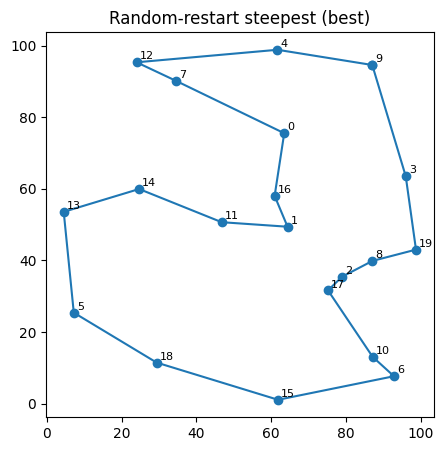

In [ ]:
# Code goes here
# Random-restart steepest-ascent: chạy nhiều khởi tạo và chọn tốt nhất
def random_restart_steepest(tsp, restarts=10, max_iters=1000):
    best_tour = None
    best_len = float('inf')
    history = []
    n = len(tsp["pos"])
    for r in range(restarts):
        init = random_tour(n)
        tour, length, iters = steepest_ascent_2opt(tsp, init_tour=init, max_iters=max_iters)
        history.append((tour, length, iters))
        if length < best_len:
            best_len = length
            best_tour = tour
    return best_tour, best_len, history

# Example
best_rr_tour, best_rr_len, rr_history = random_restart_steepest(tsp, restarts=20, max_iters=1000)
print(f"Random-restart best length (20 restarts): {best_rr_len:.6f}")
show_tsp(tsp, best_rr_tour, title="Random-restart steepest (best)")


## Stochastic Hill Climbing [1 Points]

Chooses randomly from among all uphill moves.

Stochastic hill climbing length: 448.518733


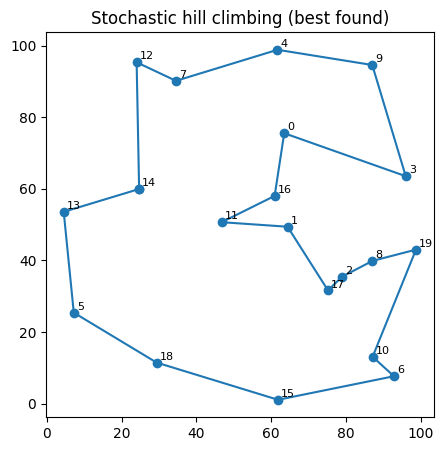

In [ ]:
# Code goes here
# Stochastic hill climbing: chọn neighbor ngẫu nhiên, chấp nhận nếu tốt hơn
def stochastic_hill_climbing(tsp, init_tour=None, iterations=10000):
    n = len(tsp["pos"])
    if init_tour is None:
        current = random_tour(n)
    else:
        current = list(init_tour)
    current_len = tour_length(tsp, current)

    for it in range(iterations):
        i = random.randint(0, n-2)
        k = random.randint(i+1, n-1)
        new = two_opt_swap(current, i, k)
        new_len = tour_length(tsp, new)
        if new_len < current_len:
            current, current_len = new, new_len
    return current, current_len

# Example
stoch_tour, stoch_len = stochastic_hill_climbing(tsp, iterations=20000)
print(f"Stochastic hill climbing length: {stoch_len:.6f}")
show_tsp(tsp, stoch_tour, title="Stochastic hill climbing (best found)")


## First-choice Hill Climbing [1 Point]

First-choice hill climbing is a type of stochastic hill climbing that generates one random local neighbor at a time and accept it if it has a better objective function value than the current state.

First-choice hill climbing length: 458.379565


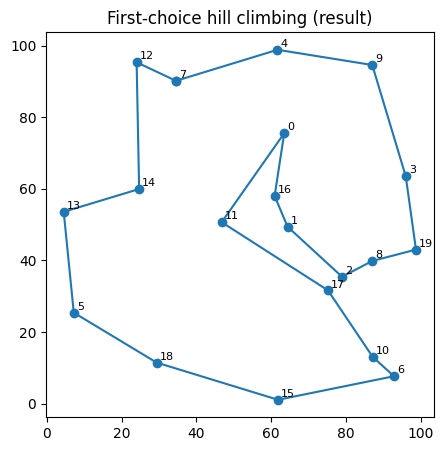

In [ ]:
# Code goes here
# First-choice hill climbing: thử neighbor ngẫu nhiên, chấp nhận lần đầu thấy cải tiến,
# dừng nếu không cải tiến trong một số lần thử liên tiếp (no_improve limit).
def first_choice_hill_climbing(tsp, init_tour=None, max_no_improve=2000):
    n = len(tsp["pos"])
    if init_tour is None:
        current = random_tour(n)
    else:
        current = list(init_tour)
    current_len = tour_length(tsp, current)
    no_improve = 0

    while no_improve < max_no_improve:
        i = random.randint(0, n-2)
        k = random.randint(i+1, n-1)
        new = two_opt_swap(current, i, k)
        new_len = tour_length(tsp, new)
        if new_len < current_len:
            current, current_len = new, new_len
            no_improve = 0
        else:
            no_improve += 1
    return current, current_len

# Example
fc_tour, fc_len = first_choice_hill_climbing(tsp, max_no_improve=5000)
print(f"First-choice hill climbing length: {fc_len:.6f}")
show_tsp(tsp, fc_tour, title="First-choice hill climbing (result)")


## Simulated Annealing [2 Points]

Simulated annealing best length: 451.955397


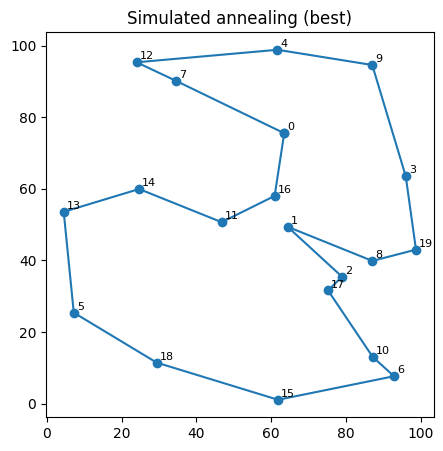

In [ ]:
# Code goes here
# Simulated annealing simple implementation (2-opt neighbor proposals)
import math

def simulated_annealing(tsp, init_tour=None, T0=1.0, alpha=0.995, iterations=5000):
    n = len(tsp["pos"])
    if init_tour is None:
        current = random_tour(n)
    else:
        current = list(init_tour)
    current_len = tour_length(tsp, current)

    best = list(current)
    best_len = current_len
    T = T0

    for it in range(iterations):
        i = random.randint(0, n-2)
        k = random.randint(i+1, n-1)
        new = two_opt_swap(current, i, k)
        new_len = tour_length(tsp, new)
        delta = new_len - current_len
        if delta < 0 or random.random() < math.exp(-delta / max(T, 1e-12)):
            current, current_len = new, new_len
            if current_len < best_len:
                best, best_len = list(current), current_len
        T *= alpha
    return best, best_len

# Example
sa_tour, sa_len = simulated_annealing(tsp, T0=1.0, alpha=0.995, iterations=20000)
print(f"Simulated annealing best length: {sa_len:.6f}")
show_tsp(tsp, sa_tour, title="Simulated annealing (best)")


## Compare Performance [2 Points]

Use runtime, scalability (number of cities), and best objective function value to compare the algorithms on boards of different sizes.  

For timing you can use the `time` package.

In [ ]:
import time

t0 = time.time()
print("Do something")
t1 = time.time()

print(f"This took: {(t1-t0) * 1e3} milliseconds")

Do something
This took: 0.17380714416503906 milliseconds


Comparison results:


,Method,Best length,Iters (if any),Time (s)
0,Steepest-ascent (single start),427.379773,13.0,0.036247
1,Random-restart steepest (20 restarts),427.379773,NaN,0.770024
2,Stochastic hill climbing,469.357336,NaN,0.403292
3,First-choice hill climbing,455.934346,NaN,0.114084
4,Simulated annealing,462.085058,NaN,0.453463


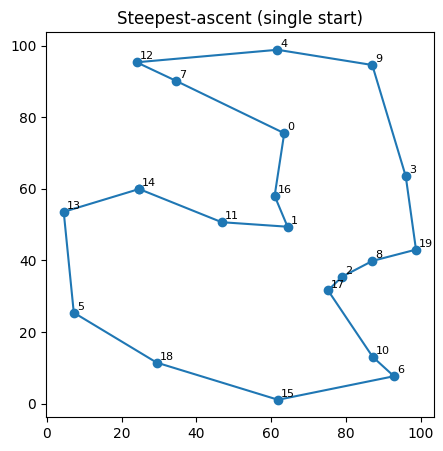

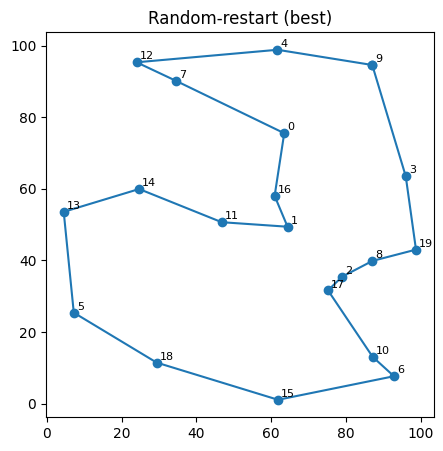

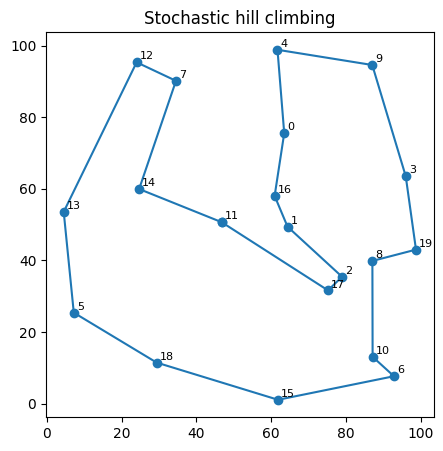

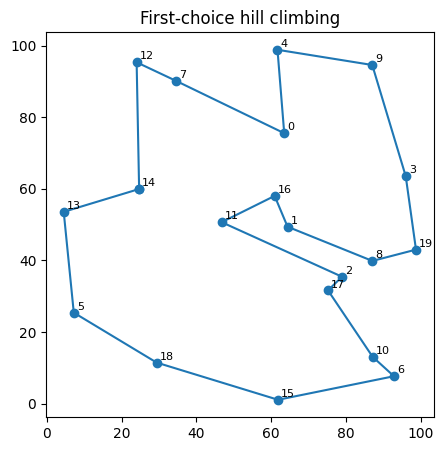

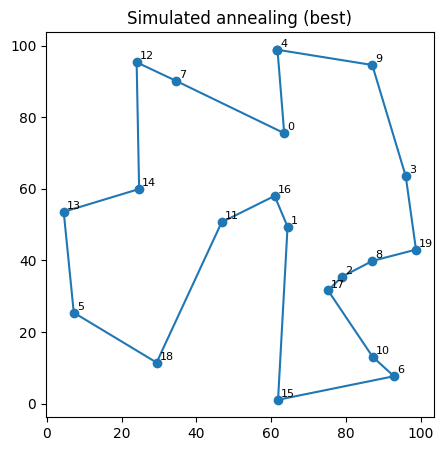

Saved comparison to tsp_compare_results.csv


In [ ]:
# Code and results go here
# Compare all methods: chạy mỗi phương pháp (tái sử dụng cùng initial or random starts as appropriate)
import time
import pandas as pd

n = len(tsp["pos"])
# choose a single random init to compare methods that use single start
init = random_tour(n)

# Steepest-ascent single start
t0 = time.time()
sa_tour, sa_len, sa_iters = steepest_ascent_2opt(tsp, init_tour=init, max_iters=1000)
t_sa = time.time() - t0

# Random-restart steepest (multiple starts)
t0 = time.time()
rr_tour, rr_len, rr_history = random_restart_steepest(tsp, restarts=20, max_iters=1000)
t_rr = time.time() - t0

# Stochastic hill climbing
t0 = time.time()
stoch_tour, stoch_len = stochastic_hill_climbing(tsp, init_tour=init, iterations=20000)
t_stoch = time.time() - t0

# First-choice hill climbing
t0 = time.time()
fc_tour, fc_len = first_choice_hill_climbing(tsp, init_tour=init, max_no_improve=5000)
t_fc = time.time() - t0

# Simulated annealing
t0 = time.time()
sa2_tour, sa2_len = simulated_annealing(tsp, init_tour=init, T0=1.0, alpha=0.995, iterations=20000)
t_sa2 = time.time() - t0

results = pd.DataFrame([
    ["Steepest-ascent (single start)", sa_len, sa_iters, t_sa],
    ["Random-restart steepest (20 restarts)", rr_len, None, t_rr],
    ["Stochastic hill climbing", stoch_len, None, t_stoch],
    ["First-choice hill climbing", fc_len, None, t_fc],
    ["Simulated annealing", sa2_len, None, t_sa2],
], columns=["Method", "Best length", "Iters (if any)", "Time (s)"])

print("Comparison results:")
display(results)

# Optional: plot the 5 best tours for visual comparison
show_tsp(tsp, sa_tour, title="Steepest-ascent (single start)")
show_tsp(tsp, rr_tour, title="Random-restart (best)")
show_tsp(tsp, stoch_tour, title="Stochastic hill climbing")
show_tsp(tsp, fc_tour, title="First-choice hill climbing")
show_tsp(tsp, sa2_tour, title="Simulated annealing (best)")

# Save results to CSV so notebook retains outputs
results.to_csv("tsp_compare_results.csv", index=False)
print("Saved comparison to tsp_compare_results.csv")


## Bonus: Genetic Algorithm [+1 Point]

GA best length: 460.049022


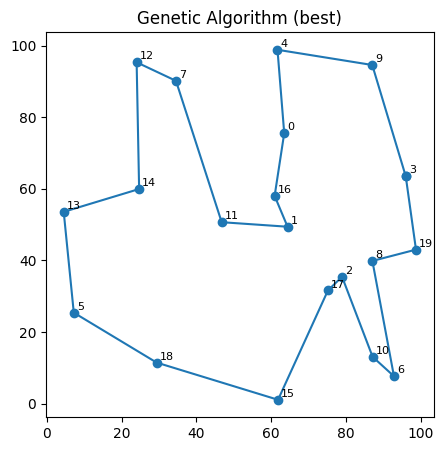

In [ ]:
# Code goes here
# Simple Genetic Algorithm for TSP (Bonus)
# Chromosome: permutation of nodes. Operators: order crossover (OX), swap mutation.

import random

def ox_crossover(parent1, parent2):
    n = len(parent1)
    a = random.randint(0, n-2)
    b = random.randint(a+1, n-1)
    hole = set(parent1[a:b+1])
    child = [-1]*n
    child[a:b+1] = parent1[a:b+1]
    idx = 0
    for gene in parent2:
        if gene in hole:
            continue
        while child[idx] != -1:
            idx += 1
        child[idx] = gene
    return child

def swap_mutation(tour, prob=0.2):
    tour = list(tour)
    if random.random() < prob:
        i = random.randrange(len(tour))
        j = random.randrange(len(tour))
        tour[i], tour[j] = tour[j], tour[i]
    return tour

def ga_tsp(tsp, pop_size=50, gens=200, cx_prob=0.8, mut_prob=0.2):
    n = len(tsp["pos"])
    # initialize population
    pop = [random_tour(n) for _ in range(pop_size)]
    fitness = [tour_length(tsp, p) for p in pop]
    best_idx = min(range(pop_size), key=lambda i: fitness[i])
    best = list(pop[best_idx])
    best_len = fitness[best_idx]

    for g in range(gens):
        # tournament selection and create offspring
        new_pop = []
        while len(new_pop) < pop_size:
            # selection
            i1, i2 = random.randrange(pop_size), random.randrange(pop_size)
            p1 = pop[i1] if fitness[i1] < fitness[i2] else pop[i2]
            i3, i4 = random.randrange(pop_size), random.randrange(pop_size)
            p2 = pop[i3] if fitness[i3] < fitness[i4] else pop[i4]
            # crossover
            if random.random() < cx_prob:
                child = ox_crossover(p1, p2)
            else:
                child = list(p1)
            # mutation
            child = swap_mutation(child, prob=mut_prob)
            new_pop.append(child)
        pop = new_pop
        fitness = [tour_length(tsp, p) for p in pop]
        idx = min(range(pop_size), key=lambda i: fitness[i])
        if fitness[idx] < best_len:
            best_len = fitness[idx]
            best = list(pop[idx])
    return best, best_len

# Example GA run (may take some time for larger gens/pop)
ga_tour, ga_len = ga_tsp(tsp, pop_size=60, gens=300, cx_prob=0.9, mut_prob=0.2)
print(f"GA best length: {ga_len:.6f}")
show_tsp(tsp, ga_tour, title="Genetic Algorithm (best)")
